### Завдання 1
Побудуйте модель лінійної регресії на одній ознаці та порахуйте якість:

- Завантажте датасет California Housing за допомогою fetch_california_housing.
- Візьміть тільки одну ознаку MedInc і випадкові 5000 рядків.
- Розділіть дані на навчальну і тестову вибірки в пропорції 80/20 з фіксованим параметром random_state=42 для відтворюваності результатів.
- Навчіть модель LinearRegression.
- Обчисліть коефіцієнт детермінації R² на тестовій вибірці.
- Виведіть результат у таблиці:

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from IPython.display import Markdown as md

In [34]:
california = fetch_california_housing(as_frame=True)
df = california.frame.sample(n=5000, random_state=42)

X = df[['MedInc']]
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

display(md("|Model|Feature|R2|\n|-|-|-|\n|LinearRegression|MedInc|%f|\n" % (r2)))

|Model|Feature|R2|
|-|-|-|
|LinearRegression|MedInc|0.496119|


### авдання 2
Порівняйте якість моделі на одній ознаці та на двох ознаках:
- Використовуйте датасет California Housing (випадкові 5000 рядків).
    - Побудуйте дві моделі:
    - ільки з ознакою MedInc;
    - з ознаками MedInc і AveRooms.
- Розділіть дані на навчальну і тестову вибірки в пропорції 80/20 з фіксованим параметром random_state=42 для відтворюваності результатів.
- Обчисліть R² на тестовій вибірці.
- Виведіть результати в таблиці:

In [35]:


california = fetch_california_housing(as_frame=True)
df = california.frame.sample(n=5000, random_state=42)
y = df['MedHouseVal']

X1 = df[['MedInc']]
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y, test_size=0.2,
    random_state=42
)
model1 = LinearRegression().fit(X1_train, y1_train)
r2_1 = r2_score(y1_test, model1.predict(X1_test))

X2 = df[['MedInc', 'AveRooms']]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2,
    random_state=42
)
model2 = LinearRegression().fit(X2_train, y2_train)
r2_2 = r2_score(y2_test, model2.predict(X2_test))

display(md("|Model|Features|R2|\n|-|-|-|\n|LinearRegression|MedInc|%f|\n|LinearRegression|MedInc, AveRooms|%f|\n" % (
    r2_1,
    r2_2
)))



|Model|Features|R2|
|-|-|-|
|LinearRegression|MedInc|0.496119|
|LinearRegression|MedInc, AveRooms|0.503710|


### Завдання 3
Обчисліть кілька метрик помилки для однієї моделі:
- Використовуйте датасет California Housing (випадкові 5000 рядків).
- Розділіть дані на навчальну і тестову вибірки в пропорції 80/20 з фіксованим параметром random_state=42 для відтворюваності результатів.
- Побудуйте модель лінійної регресії на ознаках MedInc і AveRooms.
    - На тестовій вибірці порахуйте:
    - MAE (mean_absolute_error).
    - MSE (mean_squared_error).
    - RMSE як np.sqrt(MSE).
    - R² (r2_score).
- Оформіть результати в таблиці:

In [36]:
california = fetch_california_housing(as_frame=True)
df = california.frame.sample(n=5000, random_state=42)

X = df[['MedInc', 'AveRooms']]
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

display(md("|Metric|Value|\n|-|-|\n|MAE|%f|\n|MSE|%f|\n|RMSE|%f|\n|R2|%f|\n" % (
    mae,
    mse,
    rmse,
    r2
)))


|Metric|Value|
|-|-|
|MAE|0.613654|
|MSE|0.670310|
|RMSE|0.818724|
|R2|0.503710|


### Завдання 4
Побудуйте графік для порівняння реальних і передбачених значень:

- Використовуйте датасет California Housing (випадкові 5000 рядків).
- Розділіть дані на навчальну і тестову вибірки в пропорції 80/20 з фіксованим параметром random_state=42 для відтворюваності результатів.
- Побудуйте модель лінійної регресії на ознаках MedInc і AveRooms.
- Отримайте передбачення на тестовій вибірці.
- Побудуйте scatter-графік: по осі X — y_test, по осі Y — y_pred.
- Додайте лінію y = x (ідеальні передбачення).
- Підпишіть осі та збережіть графік у файл.

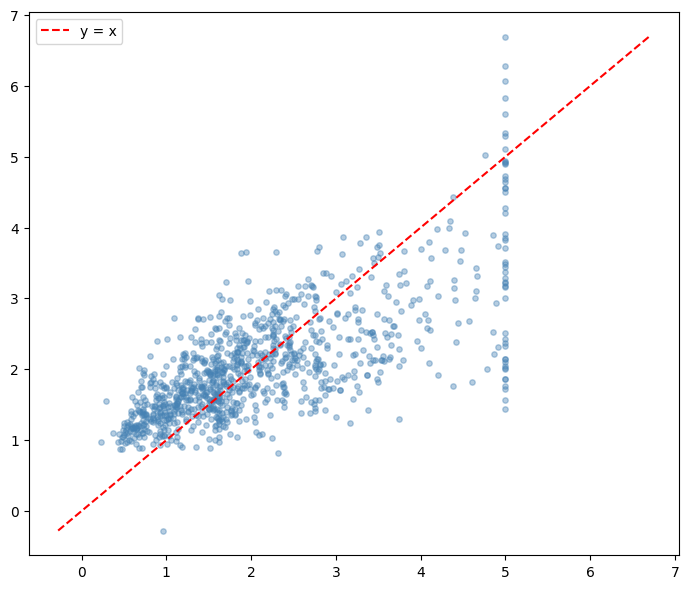

In [39]:
plt.figure(figsize=(7, 6))
plt.scatter(y2_test, y2_pred, alpha=0.4, s=15, color='steelblue')
lims = [min(y2_test.min(), y2_pred.min()), max(y2_test.max(), y2_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='y = x')
plt.legend()
plt.tight_layout()

plt.show()